In [17]:
# [code]
# 1. Import Library yang Dibutuhkan
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from supabase import create_client, Client
from dotenv import load_dotenv
import os
from datetime import datetime, timedelta

# Muat variabel lingkungan dari file .env
load_dotenv()

# --- Konfigurasi Supabase ---
# Ganti dengan nama tabel dan kolom timestamp Anda di Supabase
TABLE_NAME = "tb_konsentrasi_gas" 
TIMESTAMP_COLUMN = "created_at" 

# Ambil URL dan Key dari environment variables
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_URL or not SUPABASE_KEY:
    raise ValueError("Pastikan SUPABASE_URL dan SUPABASE_KEY sudah diatur di file .env")

# Inisialisasi klien Supabase
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

print("Library berhasil diimpor dan klien Supabase diinisialisasi.")

Library berhasil diimpor dan klien Supabase diinisialisasi.


In [18]:
# [code]
# 1. Mengambil Data Per Menit dengan Pagination (14 Hari Terakhir)

from datetime import datetime, timedelta

# Tentukan rentang waktu: 14 hari yang lalu hingga sekarang
# --- PERUBAHAN PENTING DI SINI ---
fourteen_days_ago = datetime.now() - timedelta(days=7)
print(f"Langkah 1: Mengambil data per menit dari {fourteen_days_ago.strftime('%Y-%m-%d %H:%M')}...")

# --- KODE PAGINATION ---
all_data = []
page_size = 1000
offset = 0

# Ganti nama kolom sesuai dengan yang ada di database Anda
COL_PM25 = "pm25_ugm3"
COL_CO = "co_corrected_ugm3"
COL_SUHU = "temperature"
COL_KELEMBAPAN = "humidity"
COL_TIMESTAMP = "created_at"
TABLE_NAME = "tb_konsentrasi_gas"
while True:
    print(f"Mengambil {page_size} data dimulai dari baris ke-{offset}...")
    
    response = supabase.table(TABLE_NAME) \
        .select(f"{COL_PM25}, {COL_CO}, {COL_SUHU}, {COL_KELEMBAPAN}, {COL_TIMESTAMP}") \
        .gte(COL_TIMESTAMP, fourteen_days_ago.isoformat()) \
        .order(COL_TIMESTAMP, desc=False) \
        .range(offset, offset + page_size - 1) \
        .execute()
    
    current_data = response.data
    if not current_data:
        print("Semua data telah diambil.")
        break
        
    all_data.extend(current_data)
    offset += len(current_data)

# Konversi ke DataFrame dan lakukan pembersihan seperti biasa
df_raw = pd.DataFrame(all_data)

if df_raw.empty:
    print("ERROR: Tidak ada data yang ditemukan.")
else:
    print(f"\nData mentah berhasil diambil. Total baris: {len(df_raw)}")
    for col in [COL_PM25, COL_CO, COL_SUHU, COL_KELEMBAPAN]:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    df_raw[COL_TIMESTAMP] = pd.to_datetime(df_raw[COL_TIMESTAMP])
    initial_count = len(df_raw)
    df_raw.dropna(subset=[COL_PM25, COL_CO, COL_SUHU, COL_KELEMBAPAN], inplace=True)
    final_count = len(df_raw)
    print(f"{initial_count - final_count} baris dengan nilai tidak valid telah dihapus.")
    df_clean = df_raw.set_index(COL_TIMESTAMP)
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    df_clean.sort_index(inplace=True)
    df_clean.rename(columns={
        COL_PM25: 'pm2.5', COL_CO: 'co', COL_SUHU: 'suhu', COL_KELEMBAPAN: 'kelembapan'
    }, inplace=True)
    print("Data per menit yang bersih telah disiapkan.")

Langkah 1: Mengambil data per menit dari 2025-12-04 09:14...
Mengambil 1000 data dimulai dari baris ke-0...
Mengambil 1000 data dimulai dari baris ke-1000...
Mengambil 1000 data dimulai dari baris ke-2000...
Mengambil 1000 data dimulai dari baris ke-3000...
Mengambil 1000 data dimulai dari baris ke-4000...
Mengambil 1000 data dimulai dari baris ke-5000...
Mengambil 1000 data dimulai dari baris ke-6000...
Mengambil 1000 data dimulai dari baris ke-7000...
Mengambil 1000 data dimulai dari baris ke-8000...
Mengambil 1000 data dimulai dari baris ke-9000...
Mengambil 1000 data dimulai dari baris ke-9478...
Semua data telah diambil.

Data mentah berhasil diambil. Total baris: 9478
0 baris dengan nilai tidak valid telah dihapus.
Data per menit yang bersih telah disiapkan.


In [19]:
# [code]
# 2. Resampling Data Menjadi Per Jam

if 'df_clean' in locals() and not df_clean.empty:
    print("Langkah 2: Mengelompokkan data per menit menjadi rata-rata per jam...")
    df_hourly = df_clean['pm2.5'].resample('h').mean()
    df_hourly.dropna(inplace=True)
    print(f"Jumlah titik data per jam: {len(df_hourly)}")
else:
    print("Langkah 2 dilewati karena data tidak tersedia.")

Langkah 2: Mengelompokkan data per menit menjadi rata-rata per jam...
Jumlah titik data per jam: 162


In [21]:
# [code]
# 3. Menyiapkan Data untuk Model Prophet

# Pastikan df_hourly ada dari langkah sebelumnya
if 'df_hourly' in locals() and not df_hourly.empty:
    # Buat salinan DataFrame untuk Prophet
    prophet_df = df_hourly.reset_index().copy()

    # Ubah nama kolom sesuai kebutuhan Prophet
    prophet_df = prophet_df.rename(columns={'created_at': 'ds', 'pm2.5': 'y'})

    # --- PERBAIKAN KRUSIAL: Hapus timezone ---
    if prophet_df['ds'].dt.tz is not None:
        prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)
        print("Informasi timezone telah dihapus dari kolom 'ds'.")
    
    # Prophet hanya membutuhkan kolom 'ds' dan 'y'
    prophet_df = prophet_df[['ds', 'y']]

    print("\nData untuk Prophet (5 baris pertama):")
    print(prophet_df.head())
else:
    print("Error: 'df_hourly' tidak ditemukan. Pastikan Anda sudah menjalankan langkah resampling data.")

Informasi timezone telah dihapus dari kolom 'ds'.

Data untuk Prophet (5 baris pertama):
                   ds         y
0 2025-12-04 09:00:00  3.395238
1 2025-12-04 10:00:00  3.273898
2 2025-12-04 11:00:00  3.298814
3 2025-12-04 12:00:00  3.627458
4 2025-12-04 13:00:00  4.978833


In [20]:
# [code]
# 4. Pelatihan Model Prophet

from prophet import Prophet

if 'prophet_df' in locals():
    # --- Pembagian Data (Train-Test Split) ---
    train_size = int(len(prophet_df) * 0.8)
    train_df = prophet_df.iloc[:train_size]
    test_df = prophet_df.iloc[train_size:]

    print(f"Jumlah data latih: {len(train_df)}")
    print(f"Jumlah data uji: {len(test_df)}")

    # --- Pelatihan Model ---
    print("\nMelatih model Prophet...")
    model_prophet = Prophet(
        daily_seasonality=True,  # Pola harian
        weekly_seasonality=True,  # Pola mingguan
        yearly_seasonality=False, # Non-aktifkan tahunan
        changepoint_prior_scale=0.05 # Fleksibilitas model, bisa di-tune
    )
    model_prophet.fit(train_df)
    print("Model Prophet berhasil dilatih.")
else:
    print("Langkah 4 dilewati karena data Prophet tidak tersedia.")

Langkah 4 dilewati karena data Prophet tidak tersedia.


In [13]:
# [code]
# 5. Evaluasi Performa Model Prophet

# --- Impor semua fungsi/metrik yang dibutuhkan di dalam sel ini ---
# Ini memastikan semua fungsi tersedia, tidak peduli sel mana yang sudah dijalankan sebelumnya.
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definisikan fungsi MAPE jika belum pernah didefinisikan di notebook ini
def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- Sekarang, jalankan evaluasi ---
if 'model_prophet' in locals():
    # --- Membuat Prediksi ---
    # Buat dataframe masa depan yang mencakup periode data uji
    future = model_prophet.make_future_dataframe(periods=len(test_df), freq='h')
    forecast = model_prophet.predict(future)
    
    # Ambil hanya prediksi untuk periode data uji
    y_pred_prophet = forecast['yhat'].iloc[-len(test_df):].values
    y_test_prophet = test_df['y'].values

    # --- Hitung Metrik Evaluasi ---
    mae_prophet = mean_absolute_error(y_test_prophet, y_pred_prophet)
    rmse_prophet = np.sqrt(mean_squared_error(y_test_prophet, y_pred_prophet))
    mape_prophet = mean_absolute_percentage_error(y_test_prophet, y_pred_prophet)
    r2_prophet = r2_score(y_test_prophet, y_pred_prophet)

    print("\n--- Hasil Evaluasi Model Prophet (Data 14 Hari) ---")
    print(f"Mean Absolute Error (MAE): {mae_prophet:.2f} µg/m³")
    print(f"Root Mean Squared Error (RMSE): {rmse_prophet:.2f} µg/m³")
    print(f"Mean Absolute Percentage Error (MAPE): {mape_prophet:.2f}%")
    print(f"R-squared (R²): {r2_prophet:.2f}")
    print("----------------------------------------------------")
else:
    print("Langkah 5 dilewati karena model Prophet belum dibuat.")


--- Hasil Evaluasi Model Prophet (Data 14 Hari) ---
Mean Absolute Error (MAE): 1.35 µg/m³
Root Mean Squared Error (RMSE): 1.62 µg/m³
Mean Absolute Percentage Error (MAPE): 34.83%
R-squared (R²): -1.97
----------------------------------------------------


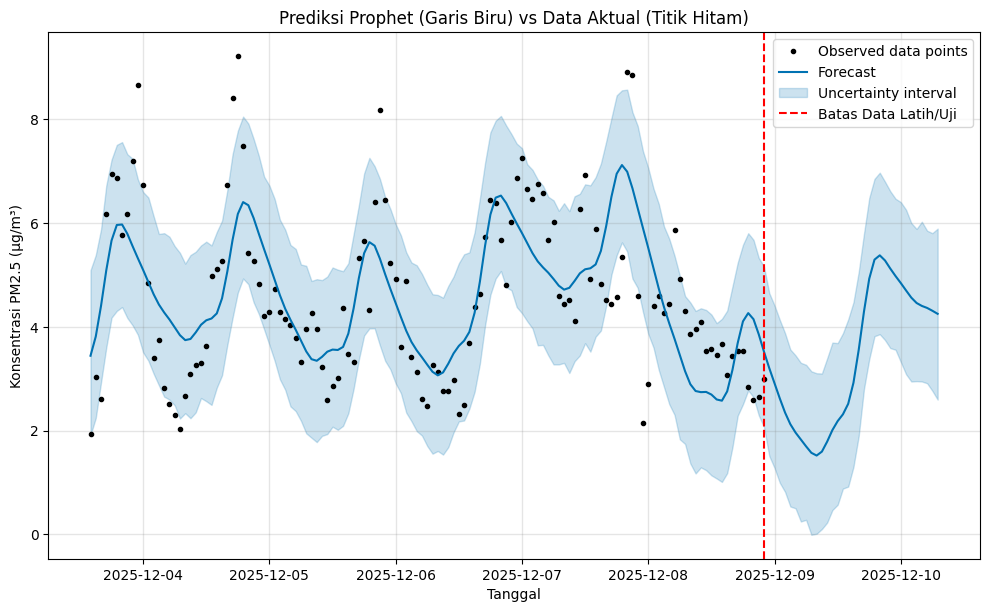

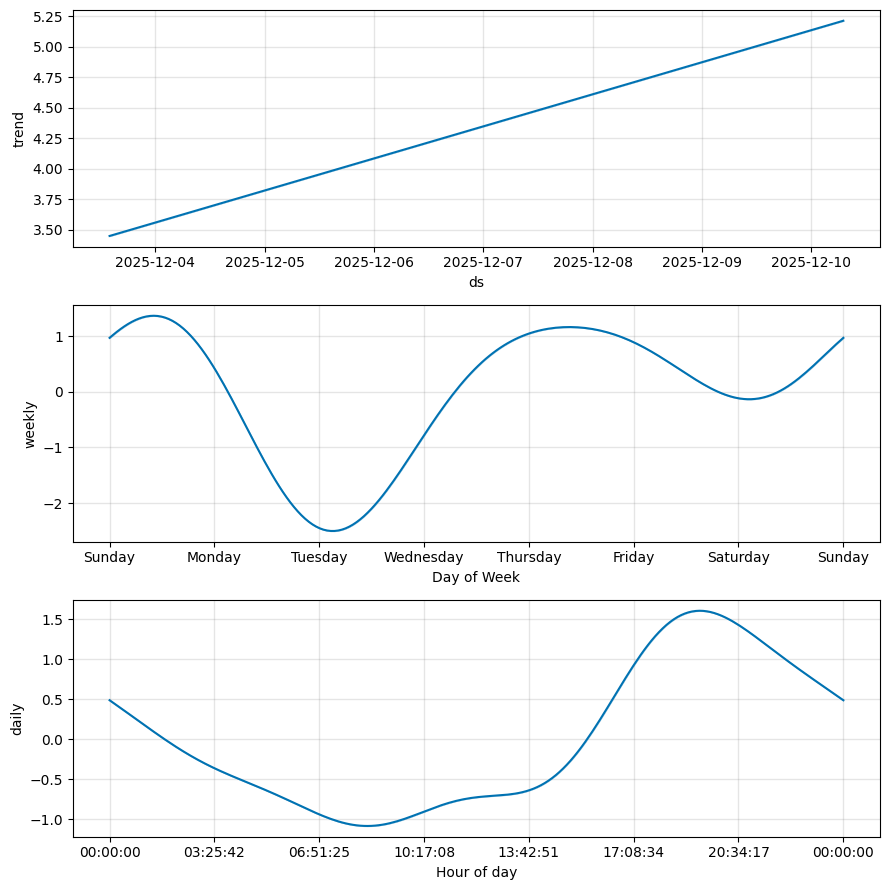

In [14]:
# [code]
# 6. Visualisasi Hasil Prophet

if 'model_prophet' in locals() and 'forecast' in locals():
    # Visualisasi 1: Plot Prediksi vs Aktual
    fig1 = model_prophet.plot(forecast)
    plt.title('Prediksi Prophet (Garis Biru) vs Data Aktual (Titik Hitam)')
    plt.xlabel('Tanggal')
    plt.ylabel('Konsentrasi PM2.5 (µg/m³)')
    ax = fig1.gca()
    # Tandai batas antara data latih dan uji
    ax.axvline(x=train_df['ds'].max(), color='red', linestyle='--', label='Batas Data Latih/Uji')
    ax.legend()
    plt.show()

    # Visualisasi 2: Komponen-komponen Pola (Tren, Musiman)
    # Ini adalah fitur andalan Prophet!
    fig2 = model_prophet.plot_components(forecast)
    plt.show()
else:
    print("Tidak bisa membuat visualisasi karena model Prophet belum dibuat.")

In [7]:
# [code]
# 1. Import Library dan Konfigurasi Supabase
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from supabase import create_client, Client
from dotenv import load_dotenv
import os
from datetime import datetime, timedelta

# Muat variabel lingkungan dari file .env
load_dotenv()

# --- Konfigurasi Supabase ---
# Ganti dengan nama tabel dan kolom Anda di Supabase
TABLE_NAME = "tb_konsentrasi_gas" 
COL_PM25 = "pm25_ugm3"
COL_CO = "co_ugm3"
COL_SUHU = "temperature"
COL_KELEMBAPAN = "humidity"
COL_TIMESTAMP = "created_at"

# Ambil URL dan Key dari environment variables
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_URL or not SUPABASE_KEY:
    raise ValueError("Pastikan SUPABASE_URL dan SUPABASE_KEY sudah diatur di file .env")

# Inisialisasi klien Supabase
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

print("Langkah 1: Lingkungan dan Supabase berhasil dikonfigurasi.")

Langkah 1: Lingkungan dan Supabase berhasil dikonfigurasi.


In [8]:
# [code]
# 2. Mengambil Data Per Menit dengan Pagination (7 Hari Terakhir)

# Kita akan menggunakan data 7 hari karena terbukti memberikan hasil terbaik
seven_days_ago = datetime.now() - timedelta(days=7)
print(f"Langkah 2: Mengambil data per menit dari {seven_days_ago.strftime('%Y-%m-%d %H:%M')}...")

# --- KODE PAGINATION ---
all_data = []
page_size = 1000
offset = 0

while True:
    print(f"Mengambil {page_size} data dimulai dari baris ke-{offset}...")
    
    response = supabase.table(TABLE_NAME) \
        .select(f"{COL_PM25}, {COL_CO}, {COL_SUHU}, {COL_KELEMBAPAN}, {COL_TIMESTAMP}") \
        .gte(COL_TIMESTAMP, seven_days_ago.isoformat()) \
        .order(COL_TIMESTAMP, desc=False) \
        .range(offset, offset + page_size - 1) \
        .execute()
    
    current_data = response.data
    if not current_data:
        print("Semua data telah diambil.")
        break
        
    all_data.extend(current_data)
    offset += len(current_data)

# Konversi ke DataFrame dan lakukan pembersihan
df_raw = pd.DataFrame(all_data)

if df_raw.empty:
    print("ERROR: Tidak ada data yang ditemukan.")
else:
    print(f"\nData mentah berhasil diambil. Total baris: {len(df_raw)}")
    
    # Konversi semua kolom ke numerik
    for col in [COL_PM25, COL_CO, COL_SUHU, COL_KELEMBAPAN]:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    
    df_raw[COL_TIMESTAMP] = pd.to_datetime(df_raw[COL_TIMESTAMP])

    # Hapus baris dengan nilai kosong
    initial_count = len(df_raw)
    df_raw.dropna(subset=[COL_PM25, COL_CO, COL_SUHU, COL_KELEMBAPAN], inplace=True)
    final_count = len(df_raw)
    print(f"{initial_count - final_count} baris dengan nilai tidak valid telah dihapus.")

    # Bersihkan dan siapkan data
    df_clean = df_raw.set_index(COL_TIMESTAMP)
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    df_clean.sort_index(inplace=True)
    df_clean.rename(columns={
        COL_PM25: 'pm2.5', COL_CO: 'co', COL_SUHU: 'suhu', COL_KELEMBAPAN: 'kelembapan'
    }, inplace=True)
    print("Data per menit yang bersih telah disiapkan.")

Langkah 2: Mengambil data per menit dari 2025-12-03 15:31...
Mengambil 1000 data dimulai dari baris ke-0...
Mengambil 1000 data dimulai dari baris ke-1000...
Mengambil 1000 data dimulai dari baris ke-2000...
Mengambil 1000 data dimulai dari baris ke-3000...
Mengambil 1000 data dimulai dari baris ke-4000...
Mengambil 1000 data dimulai dari baris ke-5000...
Mengambil 1000 data dimulai dari baris ke-6000...
Mengambil 1000 data dimulai dari baris ke-7000...
Mengambil 1000 data dimulai dari baris ke-8000...
Mengambil 1000 data dimulai dari baris ke-9000...
Mengambil 1000 data dimulai dari baris ke-9480...
Semua data telah diambil.

Data mentah berhasil diambil. Total baris: 9480
0 baris dengan nilai tidak valid telah dihapus.
Data per menit yang bersih telah disiapkan.


In [9]:
# [code]
# 3. Resampling dan Rekayasa Fitur (Feature Engineering)

if 'df_clean' in locals() and not df_clean.empty:
    print("Langkah 3: Mengelompokkan data per menit menjadi rata-rata per jam...")
    
    # Resample semua kolom numerik sekaligus
    df_hourly = df_clean.resample('h').mean()
    df_hourly.dropna(inplace=True)
    
    print(f"Jumlah titik data per jam: {len(df_hourly)}")
    
    # --- REKAYASA FITUR ---
    features_df = df_hourly.copy()
    feature_cols = ['pm2.5', 'co', 'suhu', 'kelembapan']
    
    # Buat fitur lag dan rolling untuk setiap kolom
    for col in feature_cols:
        features_df[f'{col}_lag_1h'] = features_df[col].shift(1)
        features_df[f'{col}_lag_24h'] = features_df[col].shift(24)
        features_df[f'{col}_rolling_mean_3h'] = features_df[col].rolling(window=3).mean()
        features_df[f'{col}_rolling_std_3h'] = features_df[col].rolling(window=3).std()

    # Fitur Berbasis Waktu
    features_df['hour'] = features_df.index.hour
    features_df['dayofweek'] = features_df.index.dayofweek

    # Tentukan Target (y) dan Fitur (X)
    features_df['target'] = features_df['pm2.5'].shift(-1)
    features_df.dropna(inplace=True)

    print(f"\nJumlah baris akhir setelah pembuatan fitur: {len(features_df)}")
    
    if features_df.empty:
        print("ERROR: DataFrame fitur kosong.")
    else:
        print("\n5 baris pertama dari DataFrame fitur:")
        print(features_df.head())
else:
    print("Langkah 3 dilewati.")

Langkah 3: Mengelompokkan data per menit menjadi rata-rata per jam...
Jumlah titik data per jam: 162

Jumlah baris akhir setelah pembuatan fitur: 137

5 baris pertama dari DataFrame fitur:
                              pm2.5            co       suhu  kelembapan  \
created_at                                                                 
2025-12-04 15:00:00+00:00  5.270508  57499.860000  31.847458   64.379661   
2025-12-04 16:00:00+00:00  6.729000  57151.654833  31.516667   65.116667   
2025-12-04 17:00:00+00:00  8.409661  56858.913051  31.272881   65.045763   
2025-12-04 18:00:00+00:00  9.225500  56487.707167  30.940000   66.160000   
2025-12-04 19:00:00+00:00  7.486780  56208.675763  30.806780   67.006780   

                           pm2.5_lag_1h  pm2.5_lag_24h  pm2.5_rolling_mean_3h  \
created_at                                                                      
2025-12-04 15:00:00+00:00      5.112542       3.201724               5.120628   
2025-12-04 16:00:00+00:00      5.27

In [10]:
# [code]
# 4. Persiapan Data untuk Model LightGBM

if 'features_df' in locals() and not features_df.empty:
    print("Langkah 4: Mempersiapkan data untuk model...")

    # Pisahkan fitur (X) dan target (y)
    X = features_df.drop('target', axis=1)
    y = features_df['target']

    # Pembagian data latih dan uji (Time Series Split)
    split_index = int(len(X) * 0.8)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    print(f"Ukuran data latih (X_train): {X_train.shape}")
    print(f"Ukuran data uji (X_test): {X_test.shape}")
else:
    print("Langkah 4 dilewati.")

Langkah 4: Mempersiapkan data untuk model...
Ukuran data latih (X_train): (109, 22)
Ukuran data uji (X_test): (28, 22)


In [5]:
# [code]
# 5. Pelatihan Model LightGBM

if 'X_train' in locals():
    print("Langkah 5: Melatih model LightGBM...")
    
    model_lgb = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        objective='regression',
        metric='mae',
        num_leaves=31,
        n_jobs=-1,
        random_state=42
    )

    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(50)]
    )
    
    print("Model LightGBM berhasil dilatih.")
else:
    print("Langkah 5 dilewati.")

Langkah 5: Melatih model LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 787
[LightGBM] [Info] Number of data points in the train set: 109, number of used features: 22
[LightGBM] [Info] Start training from score 4.601616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [12]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Pastikan variabel berikut sudah ada:
# X_train, X_test, y_train, y_test
# (Script ini mengasumsikan data sudah siap)
print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)


# ============================================================
# 2. DEFINISI FUNGSI OBJEKTIF UNTUK OPTUNA
# ============================================================

def objective(trial):

    param = {
        "objective": "regression",
        "metric": "mae",
        "verbosity": -1,
        "boosting_type": "gbdt",

        # =====================================================
        # HYPERPARAMETER YANG DITUNING OPTUNA
        # =====================================================
        "num_leaves": trial.suggest_int("num_leaves", 31, 255),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 5),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 1.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 2.0),
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
    }

    model = lgb.LGBMRegressor(**param)

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(100)],
    )

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)

    return mae  # Optuna akan meminimalkan MAE


# ============================================================
# 3. JALANKAN OPTUNA TUNING
# ============================================================
print("=== Memulai Hyperparameter Tuning dengan Optuna ===")

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n=== TUNING SELESAI ===")
print("Best MAE :", study.best_value)
print("Best Params :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


# ============================================================
# 4. TRAIN MODEL FINAL DENGAN PARAMETER TERBAIK
# ============================================================
best_params = study.best_params
best_params["objective"] = "regression"
best_params["metric"] = "mae"
best_params["boosting_type"] = "gbdt"
best_params["verbosity"] = -1

print("\n=== Melatih model final dengan parameter terbaik ===")

model_best = lgb.LGBMRegressor(**best_params)

model_best.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(100)],
)

print("Model terbaik selesai dilatih.")


# ============================================================
# 5. EVALUASI MODEL TERBAIK
# ============================================================

preds = model_best.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
r2 = r2_score(y_test, preds)

print("\n=== EVALUASI MODEL AKHIR (HASIL TUNING OPTUNA) ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")


# ============================================================
# 6. MODEL SIAP DIGUNAKAN UNTUK PREDIKSI
# ============================================================

print("\nModel selesai dan siap dipakai untuk forecasting 1 jam ke depan.")


c:\Users\Yusuf Rajabi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-10 15:31:58,885] A new study created in memory with name: no-name-555b2d54-4f0b-4ded-a087-1019f6042d19


Data training: (109, 22)
Data testing : (28, 22)
=== Memulai Hyperparameter Tuning dengan Optuna ===


Best trial: 3. Best value: 0.573674:  12%|█▏        | 6/50 [00:02<00:13,  3.18it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[309]	valid_0's l1: 0.614542
[I 2025-12-10 15:32:01,297] Trial 0 finished with value: 0.6145415462733984 and parameters: {'num_leaves': 93, 'max_depth': 8, 'learning_rate': 0.04251058184064246, 'feature_fraction': 0.6925325975033978, 'bagging_fraction': 0.6438253960138608, 'bagging_freq': 1, 'min_data_in_leaf': 21, 'lambda_l1': 0.037956397344822146, 'lambda_l2': 0.2160048689941918, 'n_estimators': 2867}. Best is trial 0 with value: 0.6145415462733984.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.948995
[I 2025-12-10 15:32:01,312] Trial 1 finished with value: 0.9489950150656306 and parameters: {'num_leaves': 232, 'max_depth': 10, 'learning_rate': 0.01599387660256618, 'feature_fraction': 0.6580490587689397, 'bagging_fraction': 0.9633212791085941, 'bagging_freq': 5, 'min_data_in_leaf': 81, 'lambda_l1': 0.34557167795399935,

Best trial: 3. Best value: 0.573674:  20%|██        | 10/50 [00:02<00:07,  5.08it/s]

...

[I 2025-12-10 15:32:04,275] Trial 41 finished with value: 0.4618084813167629 and parameters: {'num_leaves': 54, 'max_depth': 10, 'learning_rate': 0.037062097001318156, 'feature_fraction': 0.9291011945740073, 'bagging_fraction': 0.9408089098394258, 'bagging_freq': 4, 'min_data_in_leaf': 14, 'lambda_l1': 0.3045673878187171, 'lambda_l2': 0.12086802716278218, 'n_estimators': 2055}. Best is trial 41 with value: 0.4618084813167629.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[192]	valid_0's l1: 0.588925
[I 2025-12-10 15:32:04,361] Trial 42 finished with value: 0.58892475510693 and parameters: {'num_leaves': 31, 'max_depth': 10, 'learning_rate': 0.03918483960825887, 'feature_fraction': 0.9472172362661841, 'bagging_fraction': 0.9391853709776203, 'bagging_freq': 4, 'min_data_in_leaf': 22, 'lambda_l1': 0.2006584390845914, 'lambda_l2': 0.16032988802406817, 'n_estimators': 2020}. Best is trial 41 with value: 0.4618084813167629.
Training until va

Best trial: 41. Best value: 0.461808:  90%|█████████ | 45/50 [00:05<00:00, 12.26it/s]

Early stopping, best iteration is:
[308]	valid_0's l1: 0.572019
[I 2025-12-10 15:32:04,508] Trial 44 finished with value: 0.5720192742745359 and parameters: {'num_leaves': 49, 'max_depth': 10, 'learning_rate': 0.036715514171131725, 'feature_fraction': 0.9964533254123273, 'bagging_fraction': 0.9272033369837281, 'bagging_freq': 4, 'min_data_in_leaf': 25, 'lambda_l1': 0.32315480923532525, 'lambda_l2': 1.2105125254485762, 'n_estimators': 2388}. Best is trial 41 with value: 0.4618084813167629.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[135]	valid_0's l1: 0.585086
[I 2025-12-10 15:32:04,577] Trial 45 finished with value: 0.5850858930115678 and parameters: {'num_leaves': 65, 'max_depth': 9, 'learning_rate': 0.048332982637960056, 'feature_fraction': 0.9336567379676508, 'bagging_fraction': 0.9425717216457736, 'bagging_freq': 4, 'min_data_in_leaf': 32, 'lambda_l1': 0.4006612075410515, 'lambda_l2': 0.43245922017707134, 'n_estimators': 1895}. 

Best trial: 41. Best value: 0.461808: 100%|██████████| 50/50 [00:05<00:00,  8.42it/s]


[I 2025-12-10 15:32:04,675] Trial 46 finished with value: 0.4743740996771278 and parameters: {'num_leaves': 44, 'max_depth': 11, 'learning_rate': 0.046373148786408656, 'feature_fraction': 0.8934335766014412, 'bagging_fraction': 0.9743631337597395, 'bagging_freq': 4, 'min_data_in_leaf': 14, 'lambda_l1': 0.06560953057034685, 'lambda_l2': 0.11938278246711137, 'n_estimators': 2307}. Best is trial 41 with value: 0.4618084813167629.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.948995
[I 2025-12-10 15:32:04,723] Trial 47 finished with value: 0.9489950150656306 and parameters: {'num_leaves': 94, 'max_depth': 12, 'learning_rate': 0.04671569313182864, 'feature_fraction': 0.8975124802037499, 'bagging_fraction': 0.9747122011974564, 'bagging_freq': 4, 'min_data_in_leaf': 69, 'lambda_l1': 0.010046167591650279, 'lambda_l2': 0.8761399142990819, 'n_estimators': 2332}. Best is trial 41 with value: 0.4618084813167629.
Training until 

In [13]:
# [code]
# 6. Evaluasi Model Terbaik Hasil Tuning

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

if 'model_lgb' in locals():
    print("Langkah 6: Mengevaluasi performa model terbaik hasil tuning...")
    
    # Buat prediksi dengan model terbaik
    y_pred_tuned = model_lgb.predict(X_test)

    # Hitung semua metrik evaluasi
    mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
    rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    mape_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned)
    r2_tuned = r2_score(y_test, y_pred_tuned)

    # Tampilkan hasil evaluasi
    print("\n--- Hasil Evaluasi Model Terbaik (Hasil Tuning) ---")
    print(f"Mean Absolute Error (MAE): {mae_tuned:.2f} µg/m³")
    print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f} µg/m³")
    print(f"Mean Absolute Percentage Error (MAPE): {mape_tuned:.2f}%")
    print(f"R-squared (R²): {r2_tuned:.2f}")
    print("----------------------------------------------------")

else:
    print("Langkah 6 dilewati.")

Langkah 6: Mengevaluasi performa model terbaik hasil tuning...

--- Hasil Evaluasi Model Terbaik (Hasil Tuning) ---
Mean Absolute Error (MAE): 0.58 µg/m³
Root Mean Squared Error (RMSE): 0.75 µg/m³
Mean Absolute Percentage Error (MAPE): 14.45%
R-squared (R²): 0.38
----------------------------------------------------


In [22]:
# =========================
# ADVANCED OPTUNA TUNING for LightGBM (Time-Series CV)
# =========================
import os
import math
import joblib
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime
from optuna.exceptions import TrialPruned
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# CONFIG: sesuaikan kalau perlu
# -------------------------
TARGET_COL = "pm2.5"        # nama kolom target di features_df
TEST_RATIO = 0.2           # porsi untuk holdout terakhir
N_FOLDS = 5                # jumlah fold rolling-origin
N_TRIALS = 50              # jumlah trial Optuna
RANDOM_SEED = 42
MODEL_SAVE_PATH = "model_lgb_best.txt"

# -------------------------
# CHECK: features_df exist?
# -------------------------
if "features_df" not in globals():
    raise RuntimeError("Tidak menemukan `features_df`. Siapkan dataframe fitur (index datetime) dan kolom target 'pm25' sebelum menjalankan script ini.")

df = features_df.copy()
if TARGET_COL not in df.columns:
    raise RuntimeError(f"Kolom target '{TARGET_COL}' tidak ditemukan di features_df. Sesuaikan TARGET_COL.")

# Pastikan data terurut (time index)
if not isinstance(df.index, pd.DatetimeIndex):
    raise RuntimeError("Index features_df harus berupa DatetimeIndex (waktu).")

df = df.sort_index()

# -------------------------
# Split train / holdout (last chunk sebagai test/holdout)
# -------------------------
n_total = len(df)
n_test = max(1, int(n_total * TEST_RATIO))
n_train = n_total - n_test

df_train = df.iloc[:n_train].copy()
df_test = df.iloc[n_train:].copy()

X_train_all = df_train.drop(columns=[TARGET_COL]).values
y_train_all = df_train[TARGET_COL].values

X_test = df_test.drop(columns=[TARGET_COL]).values
y_test = df_test[TARGET_COL].values

print(f"Total rows: {n_total}, train rows: {len(df_train)}, holdout rows: {len(df_test)}")

# -------------------------
# Helper: create rolling-origin fold indices
# expanding training window, fixed validation window
# -------------------------
def make_time_series_folds(n_splits: int, n_train_len: int, n_val_len: int = None):
    """
    Returns list of (train_idx, val_idx) tuples using expanding window.
    If n_val_len is None, we divide remaining training window into n_splits equal blocks as validation windows.
    """
    if n_val_len is None:
        # evenly split last part of train into n_splits blocks
        # define step as floor(n_train_len / (n_splits + 1))
        step = max(1, n_train_len // (n_splits + 1))
        folds = []
        for k in range(1, n_splits + 1):
            train_end = step * k
            val_start = train_end
            val_end = val_start + step
            if val_end > n_train_len:
                val_end = n_train_len
            train_idx = np.arange(0, train_end)
            val_idx = np.arange(val_start, val_end)
            if len(val_idx) == 0:
                break
            folds.append((train_idx, val_idx))
        return folds
    else:
        # fixed validation length: create folds with expanding train until there is space for val windows
        folds = []
        start_val = n_train_len - n_splits * n_val_len
        if start_val < 1:
            raise ValueError("Not enough data for the given n_splits and n_val_len.")
        for k in range(n_splits):
            train_idx = np.arange(0, start_val + k * n_val_len)
            val_idx = np.arange(start_val + k * n_val_len, start_val + (k + 1) * n_val_len)
            folds.append((train_idx, val_idx))
        return folds

# Choose folds using training length
n_train_len = len(df_train)
folds = make_time_series_folds(N_FOLDS, n_train_len)
print(f"Generated {len(folds)} folds. Example fold sizes (train,val):", [(len(t), len(v)) for t, v in folds])

# -------------------------
# Optuna objective
# -------------------------
def objective(trial):
    # define search space
    param = {
        "objective": "regression",
        "metric": "mae",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "seed": RANDOM_SEED,
        "num_leaves": trial.suggest_int("num_leaves", 31, 256),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 0, 5),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 2.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 2.0),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 1.0),
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
    }
    # accumulate per-fold errors
    val_maes = []
    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_tr = df_train.drop(columns=[TARGET_COL]).values[train_idx]
        y_tr = df_train[TARGET_COL].values[train_idx]
        X_val = df_train.drop(columns=[TARGET_COL]).values[val_idx]
        y_val = df_train[TARGET_COL].values[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        # train with early stopping; verbose = 0 to reduce prints
        model = lgb.train(
            param,
            dtrain,
            valid_sets=[dtrain, dvalid],
            valid_names=["train", "valid"],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )


        # validation predictions (use best_iteration_)
        best_iter = model.best_iteration or param["n_estimators"]
        ypred = model.predict(X_val, num_iteration=best_iter)
        fold_mae = mean_absolute_error(y_val, ypred)
        val_maes.append(fold_mae)

        # report intermediate objective value to Optuna for pruning decisions
        trial.report(fold_mae, fold_idx)
        if trial.should_prune():
            raise TrialPruned()

    # return mean MAE across folds
    mean_mae = float(np.mean(val_maes))
    return mean_mae

# -------------------------
# Run Optuna study
# -------------------------
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
                            pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
print("Starting Optuna tuning...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Tuning finished.")
print("Best MAE:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# -------------------------
# Train final model on full training set with best params
# -------------------------
best_params = study.best_params.copy()
# ensure required entries
best_params.update({
    "objective": "regression",
    "metric": "mae",
    "boosting_type": "gbdt",
    "verbosity": -1,
    "seed": RANDOM_SEED
})

# Train final on full training DF (train_all)
X_train_full = df_train.drop(columns=[TARGET_COL]).values
y_train_full = df_train[TARGET_COL].values

dtrain_full = lgb.Dataset(X_train_full, label=y_train_full)

print("Training final model on full training set...")
model_final = lgb.train(
    best_params,
    dtrain_full,
    num_boost_round=best_params.get("n_estimators", 1000),
    callbacks=[lgb.log_evaluation(period=0)]
)

# Save model
model_final.save_model(MODEL_SAVE_PATH)
print(f"Final model saved to {MODEL_SAVE_PATH}")

# -------------------------
# Evaluate final model on holdout test
# -------------------------
y_pred_test = model_final.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = math.sqrt(mean_squared_error(y_test, y_pred_test))
mape = np.mean(np.abs((y_test - y_pred_test) / np.where(y_test==0, 1e-8, y_test))) * 100
r2 = r2_score(y_test, y_pred_test)

print("\n=== Final evaluation on holdout test ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# Optional: show last few predictions vs actual
df_eval = pd.DataFrame({
    "actual": y_test,
    "pred": y_pred_test
}, index=df_test.index)
print("\nLast 10 holdout rows (actual vs pred):")
print(df_eval.tail(10))

# Done
print("\nOptuna + TimeSeries CV tuning complete.")


Total rows: 137, train rows: 110, holdout rows: 27
Generated 5 folds. Example fold sizes (train,val): [(18, 18), (36, 18), (54, 18), (72, 18), (90, 18)]
Starting Optuna tuning...


Best trial: 14. Best value: 0.720831: 100%|██████████| 50/50 [00:05<00:00,  8.78it/s]


Tuning finished.
Best MAE: 0.7208308635391436
Best params:
  num_leaves: 183
  max_depth: 5
  learning_rate: 0.04317497971365168
  min_data_in_leaf: 5
  feature_fraction: 0.7495910822966338
  bagging_fraction: 0.912415457654784
  bagging_freq: 4
  lambda_l1: 1.958851183545489
  lambda_l2: 0.28316848330470257
  min_gain_to_split: 0.5310875548168796
  n_estimators: 1300
Training final model on full training set...
Final model saved to model_lgb_best.txt

=== Final evaluation on holdout test ===
MAE  : 0.4338
RMSE : 0.5199
MAPE : 11.42%
R²   : 0.7123

Last 10 holdout rows (actual vs pred):
                             actual      pred
created_at                                   
2025-12-09 22:00:00+00:00  4.669661  4.028096
2025-12-09 23:00:00+00:00  3.089322  3.945857
2025-12-10 00:00:00+00:00  3.298000  3.673846
2025-12-10 01:00:00+00:00  3.403390  3.380566
2025-12-10 02:00:00+00:00  3.859333  4.025412
2025-12-10 03:00:00+00:00  4.723390  4.188031
2025-12-10 04:00:00+00:00  4.377458  4